# Laboratório 04: Identificação e Visualização de Dados Ausentes

**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Professor:** Luís Aramis

**Objetivo:** Aplicar técnicas de diagnóstico para identificar, quantificar e visualizar "buracos" (valores nulos) em conjuntos de dados reais, além de integrar conceitos de análise exploratória e qualidade de dados acumulados nas aulas anteriores.


In [1]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os gráficos
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Ignorar avisos de depreciação para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')


## Parte 1: Exemplo Guiado - O "Raio-X" do Dirty Iris

Neste exemplo, vamos carregar o dataset `dirty_iris`, uma versão corrompida propositalmente do famoso dataset de plantas Iris. Vamos entender como o Pandas lida com o "nada" (`NaN`) e como podemos usar a biblioteca Seaborn para visualizar a gravidade da ausência de dados.


--- Relatório de Completude ---
              Total Nulos  % de Ausência
Petal.Length           19      12.666667
Sepal.Width            17      11.333333
Petal.Width            12       8.000000
Sepal.Length           10       6.666667


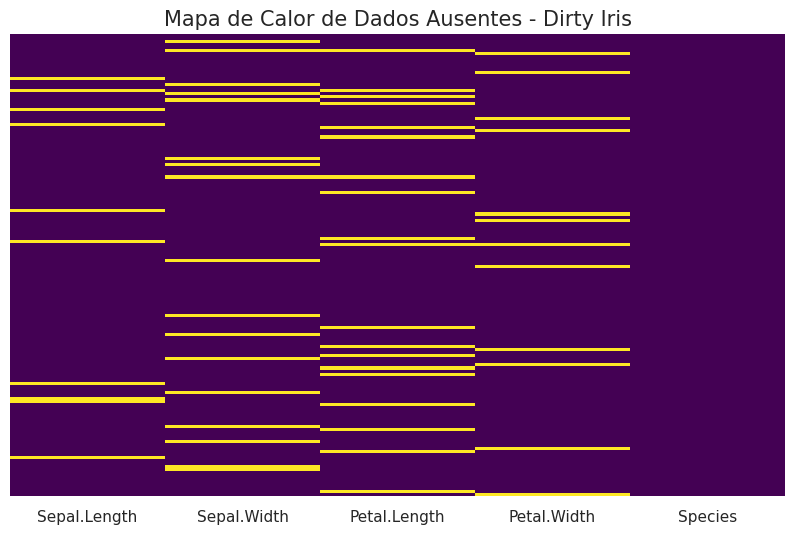

In [2]:
# 1. Carga dos dados (Usando a URL do repositório de Data Cleaning do R/CRAN)
url_dirty_iris = 'https://raw.githubusercontent.com/edwindj/datacleaning/master/data/dirty_iris.csv'
df_exemplo = pd.read_csv(url_dirty_iris)

# 2. Diagnóstico Rápido: Quantidade Absoluta e Percentual de Nulos
nulos_absolutos = df_exemplo.isnull().sum()
nulos_percentual = (df_exemplo.isnull().sum() / len(df_exemplo)) * 100

# Criando um DataFrame para exibir o relatório de completude de forma elegante
relatorio_nulos = pd.DataFrame({
    'Total Nulos': nulos_absolutos,
    '% de Ausência': nulos_percentual
})
print("--- Relatório de Completude ---")
print(relatorio_nulos[relatorio_nulos['Total Nulos'] > 0].sort_values(by='% de Ausência', ascending=False))

# 3. Visualização (Mapa de Calor)
plt.figure(figsize=(10, 6))
# O sns.heatmap vai pintar com uma cor brilhante onde df.isnull() for True
sns.heatmap(df_exemplo.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Dados Ausentes - Dirty Iris', fontsize=15)
plt.show()


## Parte 2: Exercício Prático (Mão na Massa) - Saúde Pública Brasileira (SIM)

Agora é a sua vez! Estamos trabalhando com uma amostra baseada no **Sistema de Informação sobre Mortalidade (SIM)** do DATASUS (2024).

Na vida real, a coluna de escolaridade (`SERIESCFAL`) frequentemente apresenta graves problemas de preenchimento e dados ausentes.

**Sua Tarefa:**

1. Execute a célula abaixo para gerar nossa amostra simulada baseada na base do DATASUS.
2. Escreva o código para descobrir **quantos** dados faltam em cada coluna.
3. Plote um gráfico de barras ordenado mostrando o _percentual_ de ausência de cada coluna.


In [5]:
# NÃO ALTERE ESTE CÓDIGO - Geração de dados simulados baseados no SIM/DATASUS
np.random.seed(42)
df_sim = pd.DataFrame({
    'DTOBITO': pd.date_range(start='2024-01-01', periods=1000, freq='h'),
    'IDADE': np.random.randint(0, 100, 1000),
    'SEXO': np.random.choice(1, 1000),
    'RACACOR': np.random.choice(1, 1000),
    'SERIESCFAL': np.random.choice(['Nenhuma', '1 a 3 anos', '4 a 7 anos', '8 a 11 anos'], 1000),
    'CAUSABAS': ['I279', 'A09', 'E112', 'I219', 'N19'] * 200
})

# Plantando os buracos (Simulando a realidade de sistemas de saúde pública)
df_sim.loc[np.random.choice(1000, 650, replace=False), 'SERIESCFAL'] = np.nan # 65% de ausência
df_sim.loc[np.random.choice(1000, 85, replace=False), 'IDADE'] = np.nan # 8.5% de ausência
df_sim.loc[np.random.choice(1000, 15, replace=False), 'CAUSABAS'] = np.nan


In [ ]:
# Passo 1: Calcule a soma e o percentual de nulos do DataFrame `df_sim`
nulos = df_sim.isna().sum()
total = df_sim.count()
percentual = nulos/total

print("Existem:\n", nulos, "\n dados nulos por coluna", "\n o que reprenta", percentual, "\n do total\n", total)

Existem:
 DTOBITO         0
IDADE          85
SEXO            0
RACACOR         0
SERIESCFAL    650
CAUSABAS       15
dtype: int64 
 dados nulos por coluna 
 o que reprenta DTOBITO       0.000000
IDADE         0.092896
SEXO          0.000000
RACACOR       0.000000
SERIESCFAL    1.857143
CAUSABAS      0.015228
dtype: float64 
 do total
 DTOBITO       1000
IDADE          915
SEXO          1000
RACACOR       1000
SERIESCFAL     350
CAUSABAS       985
dtype: int64


In [16]:
percentual

DTOBITO       0.000000
IDADE         0.092896
SEXO          0.000000
RACACOR       0.000000
SERIESCFAL    1.857143
CAUSABAS      0.015228
dtype: float64

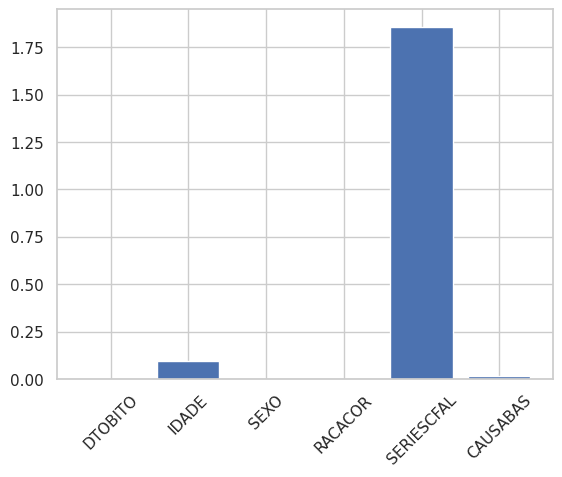

In [19]:
# Passo 2: Crie um gráfico (sugestão: gráfico de barras do Pandas ou Seaborn) que exiba o percentual de nulos visualmente.
import matplotlib.pyplot as plt 

plt.bar(percentual.index, percentual.values)
plt.xticks(rotation =45)
plt.show()

**Conclusão Final (Responda Abaixo):**
Observando o grau de dados ausentes gerado na Parte 2 (SIM/DATASUS), se você constatasse que a coluna de Escolaridade (`SERIESCFAL`) de fato possui 65% a 70% de dados ausentes, qual seria a sua decisão como analista para a próxima aula? Você deletaria a coluna inteira (`dropna(axis=1)`) ou tentaria preencher (`fillna()`) as informações? Justifique brevemente com base no risco de viés estatístico.


Eu removeria ela, porque considerando 70% de valores ausentes, o preenchimento com a média ou mediana traria um forte viés estatístico. 

---

## Parte 3: Desafio para Casa - O Auditor de Dados (Avaliação Cumulativa)

Este desafio consolida todo o seu aprendizado desde a **Aula 02 até a Aula 06**.
Você atuará sobre uma versão bagunçada baseada no dataset real **Global Shark Attacks** (Ataques de Tubarão).

**Sua Missão Completa:**

1. **Carga e Encoding (Aula 02):** Execute a célula abaixo, que irá gerar um CSV sujo no seu computador. Carregue este arquivo (`shark_attacks_messy.csv`) em um novo DataFrame prestando atenção no separador (`sep=';'`) e no encoding brasileiro legado (`encoding='latin-1'`).
2. **Qualidade e Acurácia (Aula 05):** Verifique se existem linhas inteiras duplicadas no seu dataset. Se sim, contabilize o volume de duplicatas e remova-as usando `.drop_duplicates(inplace=True)`.
3. **Tipagem e Memória (Aula 04):** A coluna `Tipo_Ataque` é composta por texto repetitivo ('Provocado', 'Não Provocado'). Converta-a para o tipo `category` para economizar memória e comprove com `.dtypes`.
4. **Mapeamento de Nulos (Aula 06):** Rastreie os valores ausentes. Gere o `heatmap` com o Seaborn para visualizar o padrão dos buracos no seu dataset de tubarões.
5. **Análise Exploratória (Aula 04):** Ignorando os nulos, agrupe os dados (`groupby`) e descubra qual é a média de `Idade_Vitima` agrupado pelo `Pais` do ataque.

_Bom trabalho! Não esqueça de comitar seu notebook no GitHub ao finalizar._


In [36]:
# NÃO ALTERE ESTE CÓDIGO - Geração e exportação do arquivo sujo
df_sharks = pd.DataFrame({
    'ID_Caso': range(1, 801),
    'Tipo_Ataque': np.random.choice(['Não Provocado', 'Provocado', 'Desastre Marítimo'], 800),
    'Pais': np.random.choice(['USA', 'AUSTRALIA', 'BRAZIL', 'SOUTH AFRICA'], 800),
    'Idade_Vitima': np.random.randint(10, 80, 800),
    'Especie_Tubarao': np.random.choice(['Tubarão Branco', 'Tubarão Tigre', 'Tubarão Cabeça-Chata', 'Desconhecido'], 800)
})

# Inserindo nulos (Simulando registros policiais incompletos)
df_sharks.loc[df_sharks['Especie_Tubarao'] == 'Desconhecido', 'Especie_Tubarao'] = np.nan # Simulação de MNAR
df_sharks.loc[np.random.choice(800, 180, replace=False), 'Idade_Vitima'] = np.nan

# Inserindo duplicatas (Simulando erro de extração)
df_sharks = pd.concat([df_sharks, df_sharks.sample(45)], ignore_index=True)

# Salvando no disco com características "sujas" brasileiras (Ponto e Vírgula e Latin-1)
df_sharks.to_csv('/home/julia/IBMEC/ETL/data-extraction-course/Atividades/data/lab4/shark_attacks_messy.csv', sep=';', encoding='latin-1', index=False)
print("Arquivo 'shark_attacks_messy.csv' gerado com sucesso para o desafio!")


Arquivo 'shark_attacks_messy.csv' gerado com sucesso para o desafio!


In [ ]:
# 1. Carregar o CSV lidando com sep e encoding
sharks = pd.read_csv('/home/julia/IBMEC/ETL/data-extraction-course/Atividades/data/lab4/shark_attacks_messy.csv', encoding='latin-1', sep = ';')


In [38]:
# 2. Auditoria e remoção de duplicatas
duplicados = sharks[sharks.duplicated()]
duplicados.shape[0]

45

In [39]:
#Remoção dos duplicados 
sharks.drop_duplicates(inplace=True)

In [ ]:
#Validando se foram removidos
sharks[sharks.duplicated()]

,ID_Caso,Tipo_Ataque,Pais,Idade_Vitima,Especie_Tubarao


In [43]:
# 3. Conversão de tipo (Category)
sharks['Tipo_Ataque'] =sharks['Tipo_Ataque'].astype('category')

In [45]:
sharks['Tipo_Ataque'].dtypes

CategoricalDtype(categories=['Desastre Marítimo', 'Não Provocado', 'Provocado'], ordered=False, categories_dtype=str)

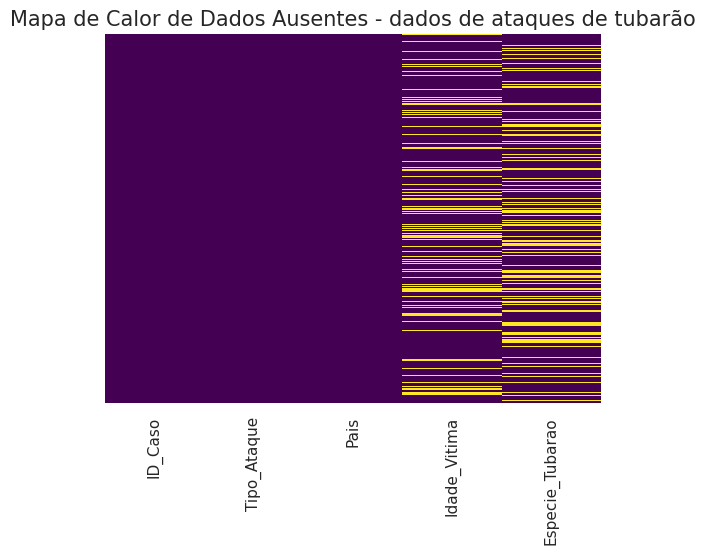

In [51]:
# 4. Heatmap de nulos (Raio-X da completude)
sns.heatmap(sharks.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Dados Ausentes - dados de ataques de tubarão', fontsize=15)
plt.show()


In [ ]:
# 5. Groupby (Análise da Idade da Vítima por País)
sharks.groupby('Pais')['Idade_Vitima'].mean()

Pais
AUSTRALIA       44.798658
BRAZIL          43.908497
SOUTH AFRICA    45.078947
USA             47.927711
Name: Idade_Vitima, dtype: float64